In [1]:
# === Core Python ===
import os
import collections
from datetime import datetime
import datetime as dt
import json 
import glob 
import string 

# === Numerical and Data Handling ===
import numpy as np
import numpy.ma as ma
import pandas as pd
import xarray as xr
import xcdat as xcd
import xskillscore as xs
from scipy.stats import pearsonr
from scipy.signal import butter, filtfilt, sosfilt, lfilter
from skimage.feature import peak_local_max

# === Plotting ===
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
from matplotlib.patches import Polygon
from matplotlib import ticker
from matplotlib.ticker import MultipleLocator
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm,BoundaryNorm

# === Mapping and Geospatial ===
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as sticker
from cartopy.mpl.ticker import LongitudeFormatter


In [2]:
class E3SMBiasPlotter:
    """
    Minimal plotting utilities for E3SM zonal-mean bias products.

    Assumptions:
      - Inputs are already zonal means (no lon dim) produced upstream.
      - Dataset contains 'bias_zonal' (and optionally 'sig_mask').
      - 'bias'/'ref' are not required here (kept only for potential extensions).

    Key methods:
      - plot_zonal_bias_contour(file_or_ds, ...)
      - plot_multi_model_zonal_contours(files, labels, ...)
      - plot_all_from_emc(var, exp, period, ...)  # opens {var}_{region}_{metric}_{exp}_{period}.nc
    """

    def __init__(self, metrics_path=None, out_dir=None, region=None,
                 metric="zonal_bias", seasons=("DJF","MAM","JJA","SON","ANN")):
        self.ds = None
        self.metrics_path = None
        self.out_dir = out_dir
        self.region = region
        self.metric = metric
        self.seasons = list(seasons)
        if metrics_path:
            if not os.path.isfile(metrics_path):
                raise FileNotFoundError(f"Metrics file not found: {metrics_path}")
            self.ds = xr.open_dataset(metrics_path)
            self.metrics_path = metrics_path

    # ----------------- helpers (small & focused) -----------------
    def _levels_symmetric_with_white(self, clim, *, color_bins_per_side=10, n_white_bins=2):
        """
        Make uniformly spaced levels from clim[0]..clim[1] with:
          - 'color_bins_per_side' colored bins on each side of zero
          - 'n_white_bins' central bins reserved for white
        Total bins N = 2*color_bins_per_side + n_white_bins
        """
        vmin, vmax = float(clim[0]), float(clim[1])
        if vmin >= 0 or vmax <= 0:
            # no sign change; fall back to simple linspace using both sides as 'one side'
            N = 2*color_bins_per_side + n_white_bins
            return np.linspace(vmin, vmax, N+1)
        N = 2*color_bins_per_side + n_white_bins
        return np.linspace(vmin, vmax, N+1)
    
    def _discrete_cmap_with_white_center(self, levels, base_cmap="RdBu_r", n_white_bins=2):
        """
        Build a ListedColormap aligned to 'levels' and force the central n_white_bins
        around 0 to white. Uses N+2 samples from base cmap so UNDER/OVER are distinct.
        """
        N = len(levels) - 1                      # data bins
        base = cm.get_cmap(base_cmap, N + 2)     # sample N+2 colors
        full = base(np.arange(N + 2))            # [0] .... [N+1]
    
        # bins use the *interior* colors; keep the very first/last for under/over
        bin_colors = full[1:-1].copy()           # length N
        # find where 0 sits among level edges
        k = int(np.searchsorted(levels, 0.0))    # 0 <= k <= N
        # choose n_white_bins centered at zero
        half = n_white_bins // 2
        start = max(0, k - half - (0 if n_white_bins % 2 == 0 else 1))
        stop  = min(N, k + half)
        if start == stop and 0 < k < N:          # ensure at least one white bin
            start, stop = k-1, k
        bin_colors[start:stop] = np.array([1,1,1,1])
    
        listed = mcolors.ListedColormap(bin_colors, name=f"{base_cmap}_bins")
        # use the reserved ends for extensions
        under_col = full[0]
        over_col  = full[-1]
        listed = listed.with_extremes(under=under_col, over=over_col)
    
        norm = BoundaryNorm(levels, listed.N, clip=False)  # enable UNDER/OVER
        return listed, norm
        
    def _has_season_coord(self, ds, varname="bias_zonal"):
        return (varname in ds) and ("season" in ds[varname].coords)
    
    def _available_seasons(self, ds, varname="bias_zonal"):
        if self._has_season_coord(ds, varname):
            vals = list(map(str, ds[varname].coords["season"].values.tolist()))
            return vals
        return []
        
    @staticmethod
    def _load_dataset(file_or_ds):
        if isinstance(file_or_ds, xr.Dataset):
            return file_or_ds
        if isinstance(file_or_ds, str):
            if not os.path.isfile(file_or_ds):
                raise FileNotFoundError(f"File not found: {file_or_ds}")
            return xr.open_dataset(file_or_ds)
        raise TypeError("Input must be a file path or xarray.Dataset")

    @staticmethod
    def _lat_name(ds):
        for cand in ("lat", "latitude", "y"):
            if cand in ds.coords or cand in ds.dims:
                return cand
        for v in ("bias_zonal","bias","ref"):
            if v in ds:
                for cand in ("lat","latitude","y"):
                    if cand in ds[v].dims:
                        return cand
        raise ValueError("Latitude coordinate not found.")

    @staticmethod
    def _vert_name(ds):
        for cand in ("plev","lev","level"):
            if cand in ds.coords or cand in ds.dims:
                return cand
        if "bias_zonal" in ds:
            for cand in ("plev","lev","level"):
                if cand in ds["bias_zonal"].dims:
                    return cand
        raise ValueError("Vertical coordinate not found (plev/lev/level).")

    @staticmethod
    def _to_hpa(da, vert):
        """Return (da_with_hpa_coord, is_hpa_bool)."""
        lev = da[vert]
        vals = np.asarray(lev.values)
        if np.size(vals) and np.nanmax(vals) > 2000:  # likely Pa
            lev_hpa = (lev/100.0).assign_attrs({**lev.attrs, "units": "hPa"})
            da = da.assign_coords({vert: lev_hpa})
            return da, True
        return da, ("hPa" in lev.attrs.get("units",""))

    @staticmethod
    def _already_masked_by_sig(da, sig_mask):
        m = (sig_mask < 0.5)
        try:
            frac = np.nanmean(np.isnan(da.where(m)))
        except Exception:
            frac = 0.0
        return frac > 0.95  # mostly NaN already in non-sig region

    @staticmethod
    def _unit_from_attrs(ds, var, field="bias_zonal"):
        u = ""
        if field in ds and hasattr(ds[field], "attrs"):
            u = ds[field].attrs.get("units", "") or ""
        if u: return u
        # fallbacks
        if var in ("T","TREFHT","TS"): return "°C"
        if var in ("U","V"):           return "m s$^{-1}$"
        if var in ("Z","Z3"):          return "m"
        if var in ("Q",):              return "kg kg$^{-1}$"
        if var in ("PRECT",):          return "mm day$^{-1}$"
        return ""

    @staticmethod
    def _season_slice(ds, s, varname="bias_zonal"):
        da = ds[varname]
        if "season" in da.coords:
            if s in da["season"].values:
                return da.sel(season=s)
            if "ANN" in da["season"].values:
                return da.sel(season="ANN")
            return da.isel(season=0)
        return da

    def _sig_for_season(self, ds, s):
        if "sig_mask" not in ds: return None
        sm = ds["sig_mask"]
        if "season" in sm.coords:
            if s in sm["season"].values:
                return sm.sel(season=s)
            if "ANN" in sm["season"].values:
                return sm.sel(season="ANN")
            return sm.isel(season=0)
        return sm

    @staticmethod
    def _select_p_window(da, vert, pmin=None, pmax=None):
        if pmin is None and pmax is None:
            return da
        lev = da[vert]
        mask = np.ones(lev.shape, dtype=bool)
        if pmin is not None: mask &= (lev >= pmin)
        if pmax is not None: mask &= (lev <= pmax)
        return da.sel({vert: lev.where(mask, drop=True)})

    def _suggest_clim_from(self, ds, var, seasons=None, varname="bias_zonal"):
        """Compute symmetric vmin/vmax from data (95th pct), with sensible minima by var."""
        arrs = []
        vert = self._vert_name(ds)
        seas = seasons or (list(ds["season"].values) if "season" in ds[varname].coords else ["ANN"])
        for s in seas:
            da = self._season_slice(ds, s, varname=varname)
            da, _ = self._to_hpa(da, vert)
            arrs.append(np.asarray(da.values).ravel())
        if not arrs:
            return (-5, 5)
        vals = np.concatenate(arrs)
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            return (-5, 5)
        q = np.nanpercentile(np.abs(vals), 95)
        lim = float(q) * 1.2 if np.isfinite(q) and q > 0 else 1.0
        base = {"T":5, "TS":5, "TREFHT":5, "U":2, "V":2, "Z":200, "Z3":200, "Q":2e-3, "PRECT":5}.get(var)
        if base is not None:
            lim = max(lim, base)
        return (-lim, lim)

    # --------------- significance overlays ----------------

    def _scatter_sig(self, ax, sig, latn, vert, *, step_lat=2, step_lev=1,
                     s=6, color="k", alpha=0.6, zorder=3):
        """
        Overlay dots where significance holds (sig > 0.5). Works for (lev,lat) or (season,lev,lat).
        step_* decimates to avoid clutter. 's' is marker size.
        """
        if "season" in sig.coords and sig.sizes.get("season", 0) > 0:
            sig = sig.isel(season=0)
        m = (sig > 0.5)
        if latn not in m.dims or vert not in m.dims:
            return
        m = m.isel({vert: slice(None, None, step_lev), latn: slice(None, None, step_lat)})
        if not bool(m.any()):
            return
        latv = m[latn].values
        levv = m[vert].values
        ii, jj = np.where(m.values)
        if ii.size == 0:
            return
        ax.scatter(latv[jj], levv[ii], s=s, c=color, alpha=alpha, linewidths=0, zorder=zorder)

    def _overlay_sig_hatch(self, ax, sig, latn, vert, *, hatch="..", zorder=3):
        if "season" in sig.coords and sig.sizes.get("season", 0) > 0:
            sig = sig.isel(season=0)
        m = (sig > 0.5)
        if latn not in m.dims or vert not in m.dims:
            return
        mm = m.astype(int)
        mm.plot.contourf(
            ax=ax, x=latn, y=vert, levels=[0.5, 1.5],
            colors="none", hatches=[hatch],
            add_colorbar=False, extend="neither",
            zorder=zorder, linewidths=0
        )

    # ----------------- single-file contour (lat–pressure) -----------------
    def plot_zonal_bias_contour(
        self, file_or_ds, var, exp="", period="", *,
        seasons=("ANN","SON","DJF"),
        figsize=(8, 8), clim=None, cmap="RdBu_r",
        nlevels=21, apply_sig="hatch",
        pmin=None, pmax=None, dpi=150,
        labelsize=11, titlesize=12, ticklabelsize=10, grid=False,
        equator_line=False, equator_kwargs=None, n_white_bins=2
    ):
        ds   = self._load_dataset(file_or_ds)
        latn = self._lat_name(ds)
        vert = self._vert_name(ds)
    
        data_seas = self._available_seasons(ds, "bias_zonal")
        seas = [s for s in seasons if (not data_seas or s in data_seas)] or ["ANN"]
    
        if clim is None:
            clim = self._suggest_clim_from(ds, var, seasons=seas, varname="bias_zonal")
        levels = np.linspace(clim[0], clim[1], nlevels)
    
        # Build a discrete cmap aligned with 'levels' and force the central bins to white
        listed_cmap, norm = self._discrete_cmap_with_white_center(levels, base_cmap=cmap, n_white_bins=n_white_bins)
    
        fig, axes = plt.subplots(len(seas), 1, figsize=figsize, dpi=dpi, sharex=True, constrained_layout=True)
        if len(seas) == 1:
            axes = [axes]
    
        last_im = None
        for i, s in enumerate(seas):
            ax = axes[i]
            bz = self._season_slice(ds, s, varname="bias_zonal")
            bz, is_hpa = self._to_hpa(bz, vert)
            bz = self._select_p_window(bz, vert, pmin=pmin, pmax=pmax)
    
            sm = self._sig_for_season(ds, s)
            if apply_sig == "mask" and sm is not None and not self._already_masked_by_sig(bz, sm):
                bz = bz.where(sm > 0.5)
    
            last_im = bz.plot.contourf(
                ax=ax, x=latn, y=vert,
                levels=levels, cmap=listed_cmap, norm=norm,
                add_colorbar=False, extend="both", add_labels=False
            )
    
            if sm is not None:
                if apply_sig == "hatch":
                    self._overlay_sig_hatch(ax, sm, latn, vert, hatch="..", zorder=3)
                elif apply_sig == "dots":
                    self._scatter_sig(ax, sm, latn, vert, step_lat=2, step_lev=1,
                                      s=6, color="k", alpha=0.5, zorder=3)
    
            if is_hpa or vert == "plev":
                ax.invert_yaxis()
                ylab = f"Pressure level (hPa)"
            else:
                ylab = vert
    
            ax.set_title(s, fontweight="bold", fontsize=fontsize)
            ax.set_ylabel(ylab, fontsize=labelsize)
    
            if equator_line:
                ek = dict(color="0.4", lw=0.6, alpha=0.35, ls="--", zorder=2)
                if equator_kwargs: ek.update(equator_kwargs)
                ax.axvline(0, **ek)
    
            if grid:
                ax.grid(True, which="both", alpha=0.2)
            ax.tick_params(axis="both", labelsize=fontsize*0.95)
            ax.set_xlabel("")

        axes[-1].set_xlabel("Latitude (deg)", fontsize=fontsize)
        cb_unit = self._unit_from_attrs(self._load_dataset(files[0]), var)
        cb_title = f"$\Delta$ {var} ({cb_unit})"
        cbar = fig.colorbar(last_im, ax=axes, orientation="horizontal", pad=0.10, extend="both")
        cbar.set_label(cb_title, fontsize=fontsize)
        cbar.ax.tick_params(labelsize=fontsize*0.95)
    
        #title_bits = [f"Zonal-mean bias: {var}", exp or None, self.region or None, period or None]
        #fig.suptitle(" — ".join([t for t in title_bits if t]), fontsize=titlesize, fontweight="bold")
        return fig, axes

    # --------- multi-model grid: rows=seasons, cols=models (shared cbar) ---------
    def plot_multi_model_zonal_contours(
        self, *, files, labels, var,
        seasons=("ANN","SON","DJF"),
        lim=None, cmap="RdBu_r",
        nlevels=21, apply_sig="hatch",
        pmin=None, pmax=None,
        vmin=None, vmax=None, levels=None, clim=None,
        figsize=None, fontsize=18, dpi=150,
        labelsize=11, titlesize=12, ticklabelsize=10, grid=False,
        equator_line=False, equator_kwargs=None, n_white_bins=2
    ):
        assert len(files) == len(labels), "files and labels must match length"
        n_cols = len(files)
        seas   = list(seasons)
        n_rows = len(seas)
    
        # shared clim if not provided
        if clim is None:
            vals = []
            for f in files:
                ds   = self._load_dataset(f)
                vert = self._vert_name(ds)
                for s in seas:
                    bz = self._season_slice(ds, s, "bias_zonal")
                    bz, _ = self._to_hpa(bz, vert)
                    bz = self._select_p_window(bz, vert, pmin=pmin, pmax=pmax)
                    sm = self._sig_for_season(ds, s) if apply_sig == "mask" else None
                    if sm is not None and not self._already_masked_by_sig(bz, sm):
                        bz = bz.where(sm > 0.5)
                    vals.append(np.asarray(bz.values).ravel())
            if vals:
                arr = np.concatenate(vals)
                arr = arr[np.isfinite(arr)]
                if arr.size:
                    q = np.nanpercentile(np.abs(arr), 95)
                    lim = float(q) * 1.2 if np.isfinite(q) and q > 0 else 1.0
                    base = {"T":5, "TS":5, "TREFHT":5, "U":2, "V":2, "Z":200, "Z3":200, "Q":2e-3, "PRECT":5}.get(var)
                    if base is not None:
                        lim = max(lim, base)
                    clim = (-lim, lim)
                else:
                    clim = (-5, 5)
            else:
                clim = (-5, 5)
    
        if levels is None:
            if vmin is not None and vmax is not None:
                levels = np.linspace(vmin, vmax, nlevels)
            else:
                levels = np.linspace(clim[0], clim[1], nlevels)
    
        if figsize is None:
            figsize = (4.4 * n_cols, 3.2 * n_rows)
    
        # Discrete cmap aligned to levels, force white center bins
        listed_cmap, norm = self._discrete_cmap_with_white_center(levels, base_cmap=cmap, n_white_bins=n_white_bins)
    
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, dpi=dpi, sharex="col", sharey="row", constrained_layout=False)
        if n_rows == 1 and n_cols == 1:
            axes = np.array([[axes]])
        elif n_rows == 1:
            axes = np.array([axes])
        elif n_cols == 1:
            axes = np.array([[ax] for ax in axes])
    
        def row_letter(i):
            alph = string.ascii_lowercase
            s = ""
            i0 = i
            while True:
                s = alph[i0 % 26] + s
                i0 = i0 // 26 - 1
                if i0 < 0: break
            return s
    
        last_im = None
        for j, (f, label) in enumerate(zip(files, labels)):
            ds   = self._load_dataset(f)
            latn = self._lat_name(ds)
            vert = self._vert_name(ds)
    
            for i, s in enumerate(seas):
                ax = axes[i][j]
                bz = self._season_slice(ds, s, "bias_zonal")
                bz, is_hpa = self._to_hpa(bz, vert)
                bz = self._select_p_window(bz, vert, pmin=pmin, pmax=pmax)
    
                sm = self._sig_for_season(ds, s)
                if apply_sig == "mask" and sm is not None and not self._already_masked_by_sig(bz, sm):
                    bz = bz.where(sm > 0.5)
    
                last_im = bz.plot.contourf(
                    ax=ax, x=latn, y=vert,
                    levels=levels, cmap=listed_cmap, norm=norm,
                    add_colorbar=False, extend="both", add_labels=False
                )
    
                if sm is not None:
                    if apply_sig == "hatch":
                        self._overlay_sig_hatch(ax, sm, latn, vert, hatch="..", zorder=3)
                    elif apply_sig == "dots":
                        self._scatter_sig(ax, sm, latn, vert, step_lat=2, step_lev=1,
                                          s=6, color="k", alpha=0.5, zorder=3)
    
                if is_hpa or vert == "plev":
                    ax.invert_yaxis()
                    ylab = f"Pressure level (hPa)"
                else:
                    ylab = vert
    
                if j == 0:
                    ax.set_ylabel(ylab, fontsize=fontsize*0.95)
                else:
                    ax.set_ylabel("")
    
                row_tag = row_letter(i)
                panel_label = f"({row_tag}{j+1}) {label}"
                ax.set_title("", loc="center")
                ax.set_title(panel_label, fontweight="normal", loc="left", fontsize=fontsize)
                ax.set_title(s, fontweight="normal", loc="right", fontsize=fontsize)
    
                if i == n_rows - 1:
                    ax.set_xlabel("Latitude (degree)", fontsize=fontsize*0.95)
                else:
                    ax.set_xlabel("")

                if equator_line:
                    ek = dict(color="0.4", lw=0.6, alpha=0.35, ls="--", zorder=2)
                    if equator_kwargs: ek.update(equator_kwargs)
                    ax.axvline(0, **ek)
    
                if grid:
                    ax.grid(True, which="both", alpha=0.2)
                ax.tick_params(axis="both", labelsize=fontsize*0.95)
    
        fig.subplots_adjust(wspace=0.08, hspace=0.25, right=0.88)
        cb_unit = self._unit_from_attrs(self._load_dataset(files[0]), var)
        cb_title = f"$\Delta$ {var} ({cb_unit})"
        cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
        cbar = fig.colorbar(last_im, cax=cax, extend="both")        
        cbar.set_label(cb_title, fontsize=fontsize)
        cbar.ax.tick_params(labelsize=fontsize*0.95)
    
        #title_bits = [f"Zonal-mean bias: {var}", self.region or None]
        #fig.suptitle(" — ".join([t for t in title_bits if t]) + f"  |  Seasons: {', '.join(seas)}",
        #             fontsize=fontsize, fontweight="bold", y=0.98)
        return fig, axes


    # ----------------- EMC convenience -----------------

    def _open_emc_product(self, var, exp, period):
        """Open {var}_{region}_{metric}_{exp}_{period}.nc from self.out_dir."""
        if not self.out_dir or not self.region:
            print("[WARN] out_dir/region not set")
            return None
        path = os.path.join(self.out_dir, f"{var}_{self.region}_{self.metric}_{exp}_{period}.nc")
        if not os.path.isfile(path):
            print(f"[WARN] Not found: {path}")
            return None
        return xr.open_dataset(path)

    def plot_all_from_emc(self, var, exp, period, *,
                          seasons=("ANN","SON","DJF"),
                          save_dir=None, clim=None, cmap="RdBu_r",
                          nlevels=21, apply_sig="hatch",
                          pmin=None, pmax=None, dpi=150):
        """
        Open the EMC-style product and produce a single-model, multi-season contour figure.
        """
        ds = self._open_emc_product(var, exp, period)
        if ds is None:
            return
        if clim is None:
            clim = self._suggest_clim_from(ds, var, seasons=seasons, varname="bias_zonal")
        if save_dir is None:
            save_dir = self.out_dir or "."
        os.makedirs(save_dir, exist_ok=True)

        fig, _ = self.plot_zonal_bias_contour(
            ds, var, exp, period, seasons=seasons,
            clim=clim, cmap=cmap, nlevels=nlevels,
            apply_sig=apply_sig, pmin=pmin, pmax=pmax, dpi=dpi
        )
        fname = os.path.join(save_dir, f"{var}_{self.region}_{self.metric}_{exp}_{period}_zonal.png")
        fig.savefig(fname, dpi=dpi, bbox_inches="tight")
        # plt.show()  # optional in interactive workflows
        plt.close(fig)
        print(f"Saved: {fname}")


/tmp/ipykernel_1773966/3382926500.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base = cm.get_cmap(base_cmap, N + 2)     # sample N+2 colors
/global/homes/z/zhan391/.local/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:2134: UserWarning: linewidths is ignored by contourf
  primitive = ax.contourf(x, y, z, **kwargs)
/global/homes/z/zhan391/.local/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:2134: UserWarning: linewidths is ignored by contourf
  primitive = ax.contourf(x, y, z, **kwargs)
/global/homes/z/zhan391/.local/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:2134: UserWarning: linewidths is ignored by contourf
  primitive = ax.contourf(x, y, z, **kwargs)
/global/homes/z/zhan391/.local/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:2134: UserWarning: linewi

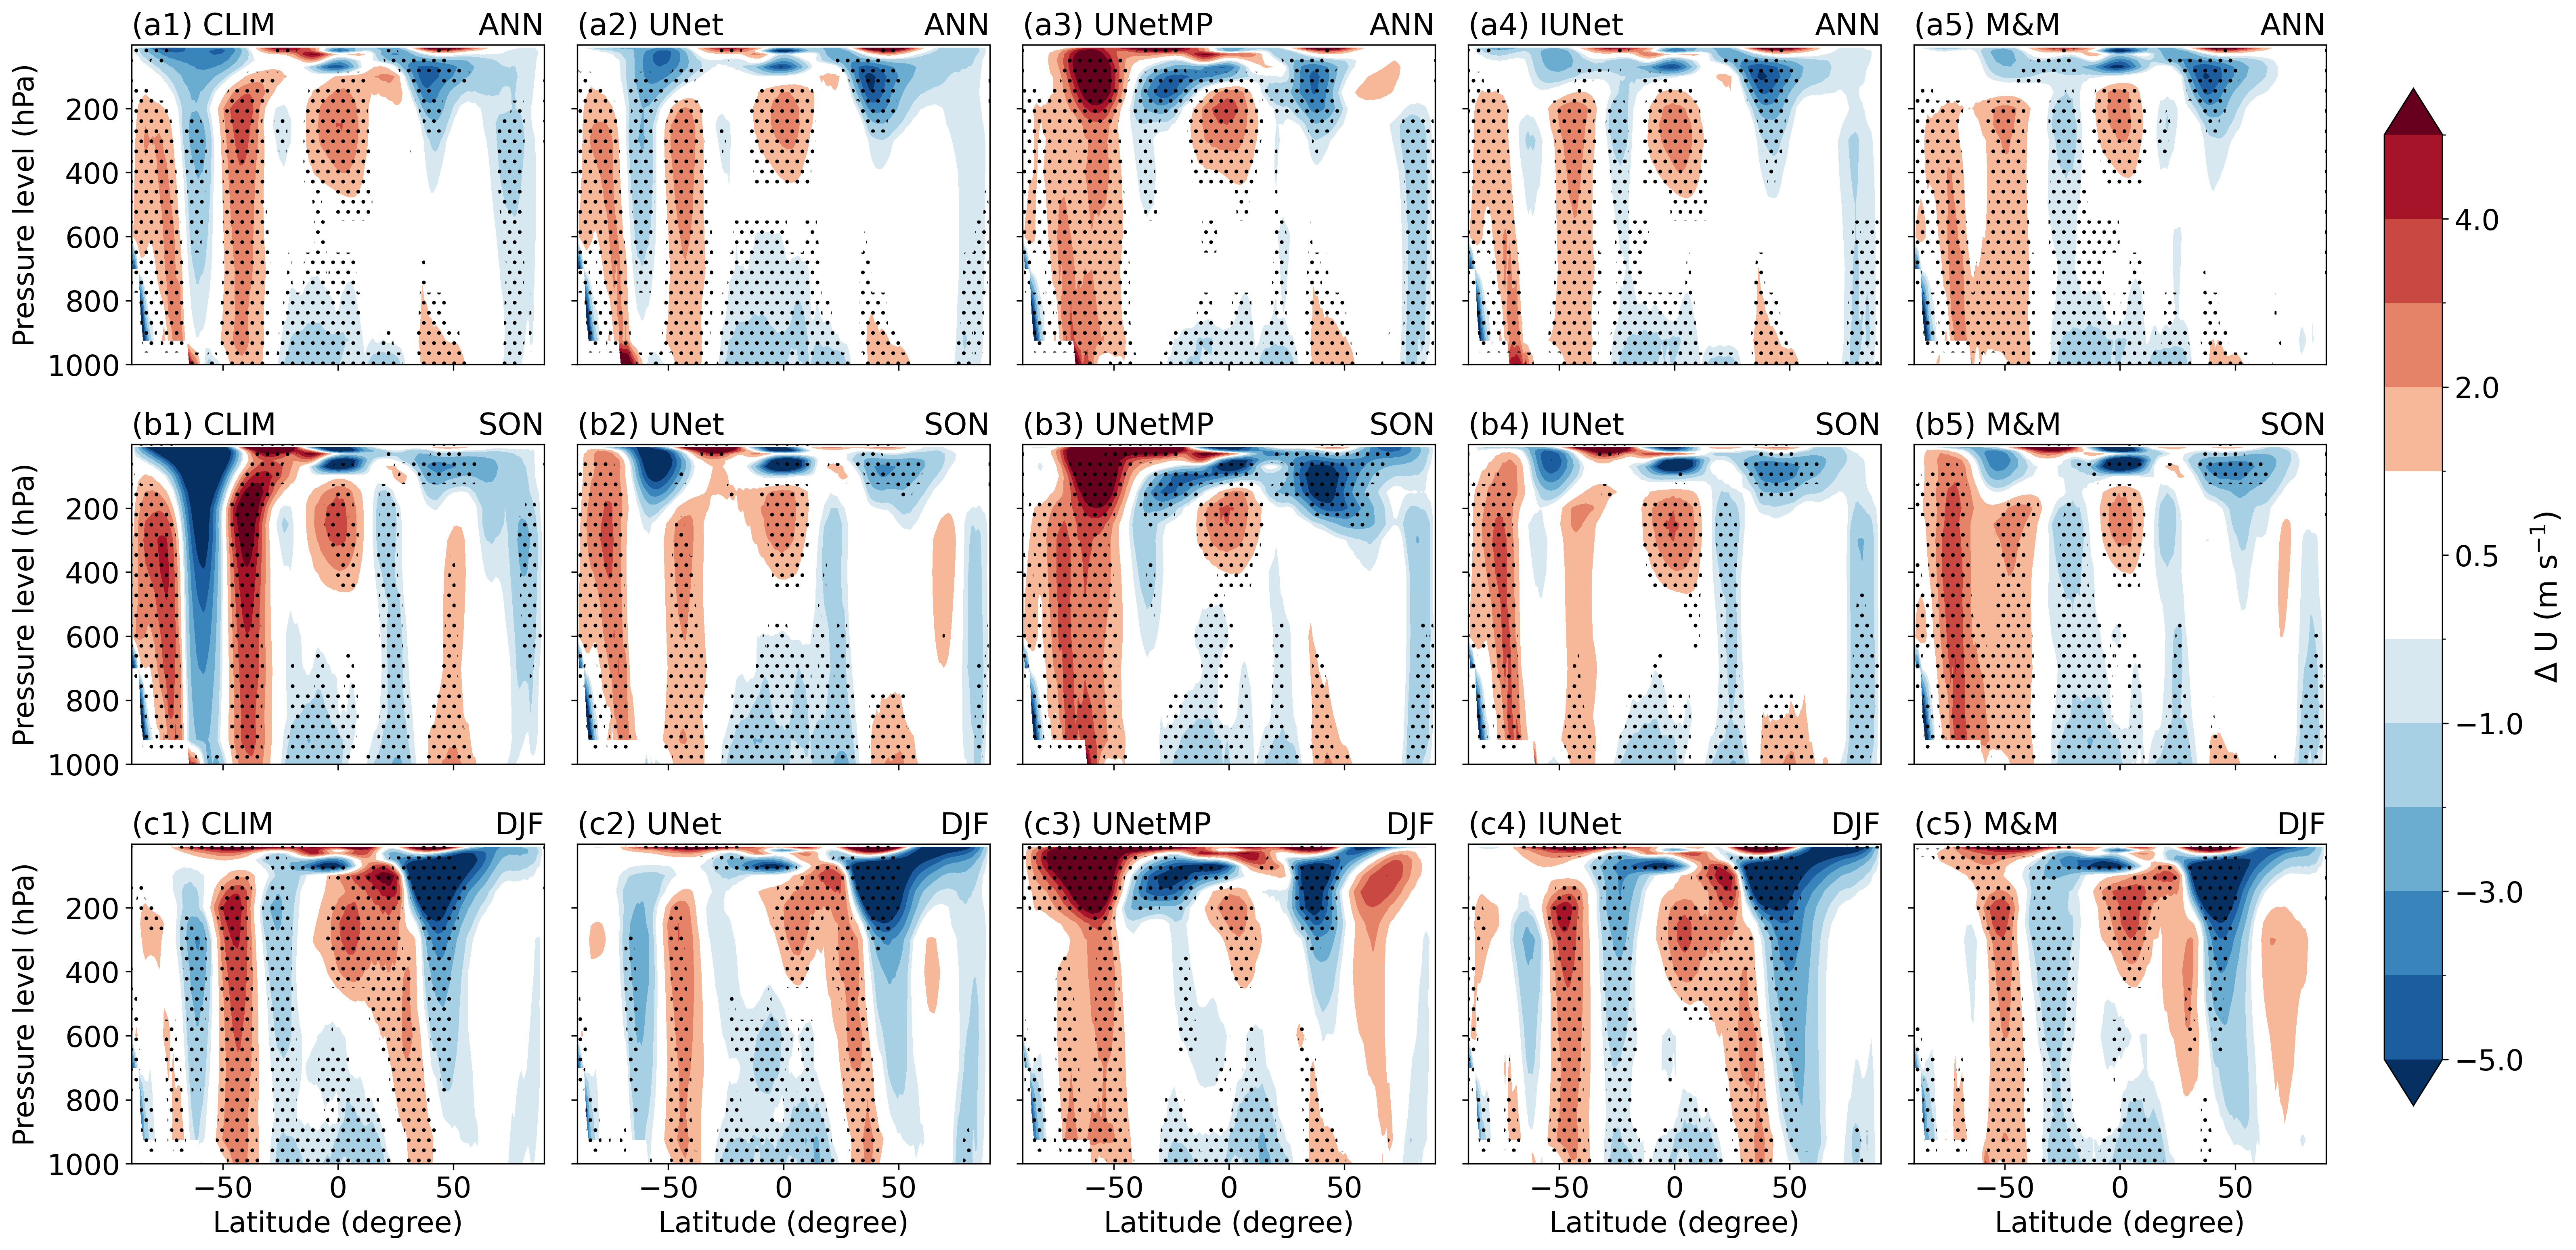

Saved: ./U_global_zonal_bias_ALLMODELS_201201_201612_ANN-SON-DJF.pdf


In [3]:
if __name__ == "__main__":
    # === Define Paths ===
    top_path  = "/pscratch/sd/z/zhan391/SEACROGS_project"
    work_path = f"{top_path}/paper_material/method_paper"
    out_path  = f"{work_path}/fig_data/zonal_bias"   # where calculator wrote NetCDFs (root)
    frequency = "monthly"                            # must match calculator.compute() path segment
    out_dir   = os.path.join(out_path, frequency)    # <out_path>/<frequency>
    fig_path  = "./"                                 # where to save PNGs
    os.makedirs(fig_path, exist_ok=True)

    # === Time / seasons ===
    period   = "201201_201612"   # must match calculator._period_label()
    seasons_all = ["DJF", "MAM", "JJA", "SON", "ANN"]
    seasons_row = ("ANN", "SON", "DJF")  # what to plot (rows)

    region = "global"
    var    = "U"                 # e.g., "U","V","T","Z","Q"
    exp    = "CLIM"              # single-experiment figure
    sigtyp = "hatch"
    metric = "zonal_bias" 
    pmin   = 10  #hPa
    pmax   = 1000 #hPa

    var_dict = {
        'U': {'alias': 'U',  'unit': 'm s$^{-1}$', 
              'fscl': 1.0, 'min': -5,  'max': 5,   
              'levs': [-5,-4,-3,-2,-1,-0.5,0.5,1,2,3,4,5]
             },
        'V': {'alias': 'V',  'unit': 'm s$^{-1}$', 
              'fscl': 1.0, 'min': -1,  'max': 1,   
              'levs': [-5,-4,-3,-2,-1,0,1,2,3,4,5]
             },
        'T': {'alias': 'T',  'unit': '°C',         
              'fscl': 1.0, 'min': -5,  'max': 5,   
              'levs': [-5,-4,-3,-2,-1,-0.5,0,0.5,1,2,3,4,5]
             },
        'Q': {'alias': 'Q',  'unit': 'g kg$^{-1}$',
              'fscl': 1.0,  'min': -1,  'max': 1,  
              'levs': [-5,-4,-3,-2,-1,-0.5,-0.2,0,0.2,0.5,1,2,3,4,5]
             },
        'Z': {'alias': 'Z3', 'unit': 'm',          
              'fscl': 1.0, 'min': -200,'max': 200, 
              'levs': [-5,-4,-3,-2,-1,-0.5,-0.2,0,0.2,0.5,1,2,3,4,5]
             },
    }
    vmin   = var_dict[var]['min']
    vmax   = var_dict[var]['max']
    nlevs  = len(var_dict[var]['levs'])
    levs   = var_dict[var]['levs']
    
    clim   = None
    dpi    = 300
    figsize =(24,12)

    # === Style (optional) ===
    fontsize = 18
    plt.rcParams.update({
        "font.size": fontsize,
        "axes.titlesize": fontsize * 0.9,
        "axes.labelsize": fontsize * 0.85,
        "xtick.labelsize": fontsize * 0.8,
        "ytick.labelsize": fontsize * 0.8,
        "legend.fontsize": fontsize * 0.75,
    })
    
    # === Experiments & variable setup ===
    exp_name_map = {
        "CLIM":   "CLIM",
        "UNet":   "UNet",
        "UNetMP": "UNetMP",
        "IUNet":  "IUNet",
        "MnM":    "M&M",
    }
    
    # Build file paths
    files = [
        os.path.join(out_dir, f"{var}_{region}_{metric}_{exp}_{period}.nc")
        for exp in exp_name_map.keys()
    ]
    
    # Corresponding labels
    labels = [exp_name_map[exp] for exp in exp_name_map.keys()]

    # === (Optional) keep a colormap handle for future tweaks ===
    index = np.linspace(0.05, 0.95, 20)
    newcmp = cm.RdYlBu_r

    # === Instantiate plotter ===
    plotter = E3SMBiasPlotter(
        out_dir=out_dir,
        region=region,
        metric=metric,
        seasons=seasons_all
    )

    fig, axes = plotter.plot_multi_model_zonal_contours(
        files=files,
        labels=labels,
        var=var,
        seasons=seasons_row,
        apply_sig=sigtyp,       # ← show significance with hatching
        pmin=pmin, 
        pmax=pmax,
        vmin=vmin,
        vmax=vmax,
        levels=levs, 
        nlevels=nlevs, 
        clim=clim,   # shared auto color scale
        figsize=figsize,
        fontsize=fontsize,
        dpi=dpi
    )
    outpdf = os.path.join(fig_path, f"{var}_{region}_{metric}_ALLMODELS_{period}_ANN-SON-DJF.pdf")
    fig.savefig(outpdf, dpi=dpi, bbox_inches="tight")
    plt.show()    
    plt.close(fig)
    print(f"Saved: {outpdf}")
    

/tmp/ipykernel_1773966/3382926500.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base = cm.get_cmap(base_cmap, N + 2)     # sample N+2 colors
/global/homes/z/zhan391/.local/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:2134: UserWarning: linewidths is ignored by contourf
  primitive = ax.contourf(x, y, z, **kwargs)
/global/homes/z/zhan391/.local/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:2134: UserWarning: linewidths is ignored by contourf
  primitive = ax.contourf(x, y, z, **kwargs)
/global/homes/z/zhan391/.local/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:2134: UserWarning: linewidths is ignored by contourf
  primitive = ax.contourf(x, y, z, **kwargs)
/global/homes/z/zhan391/.local/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:2134: UserWarning: linewi

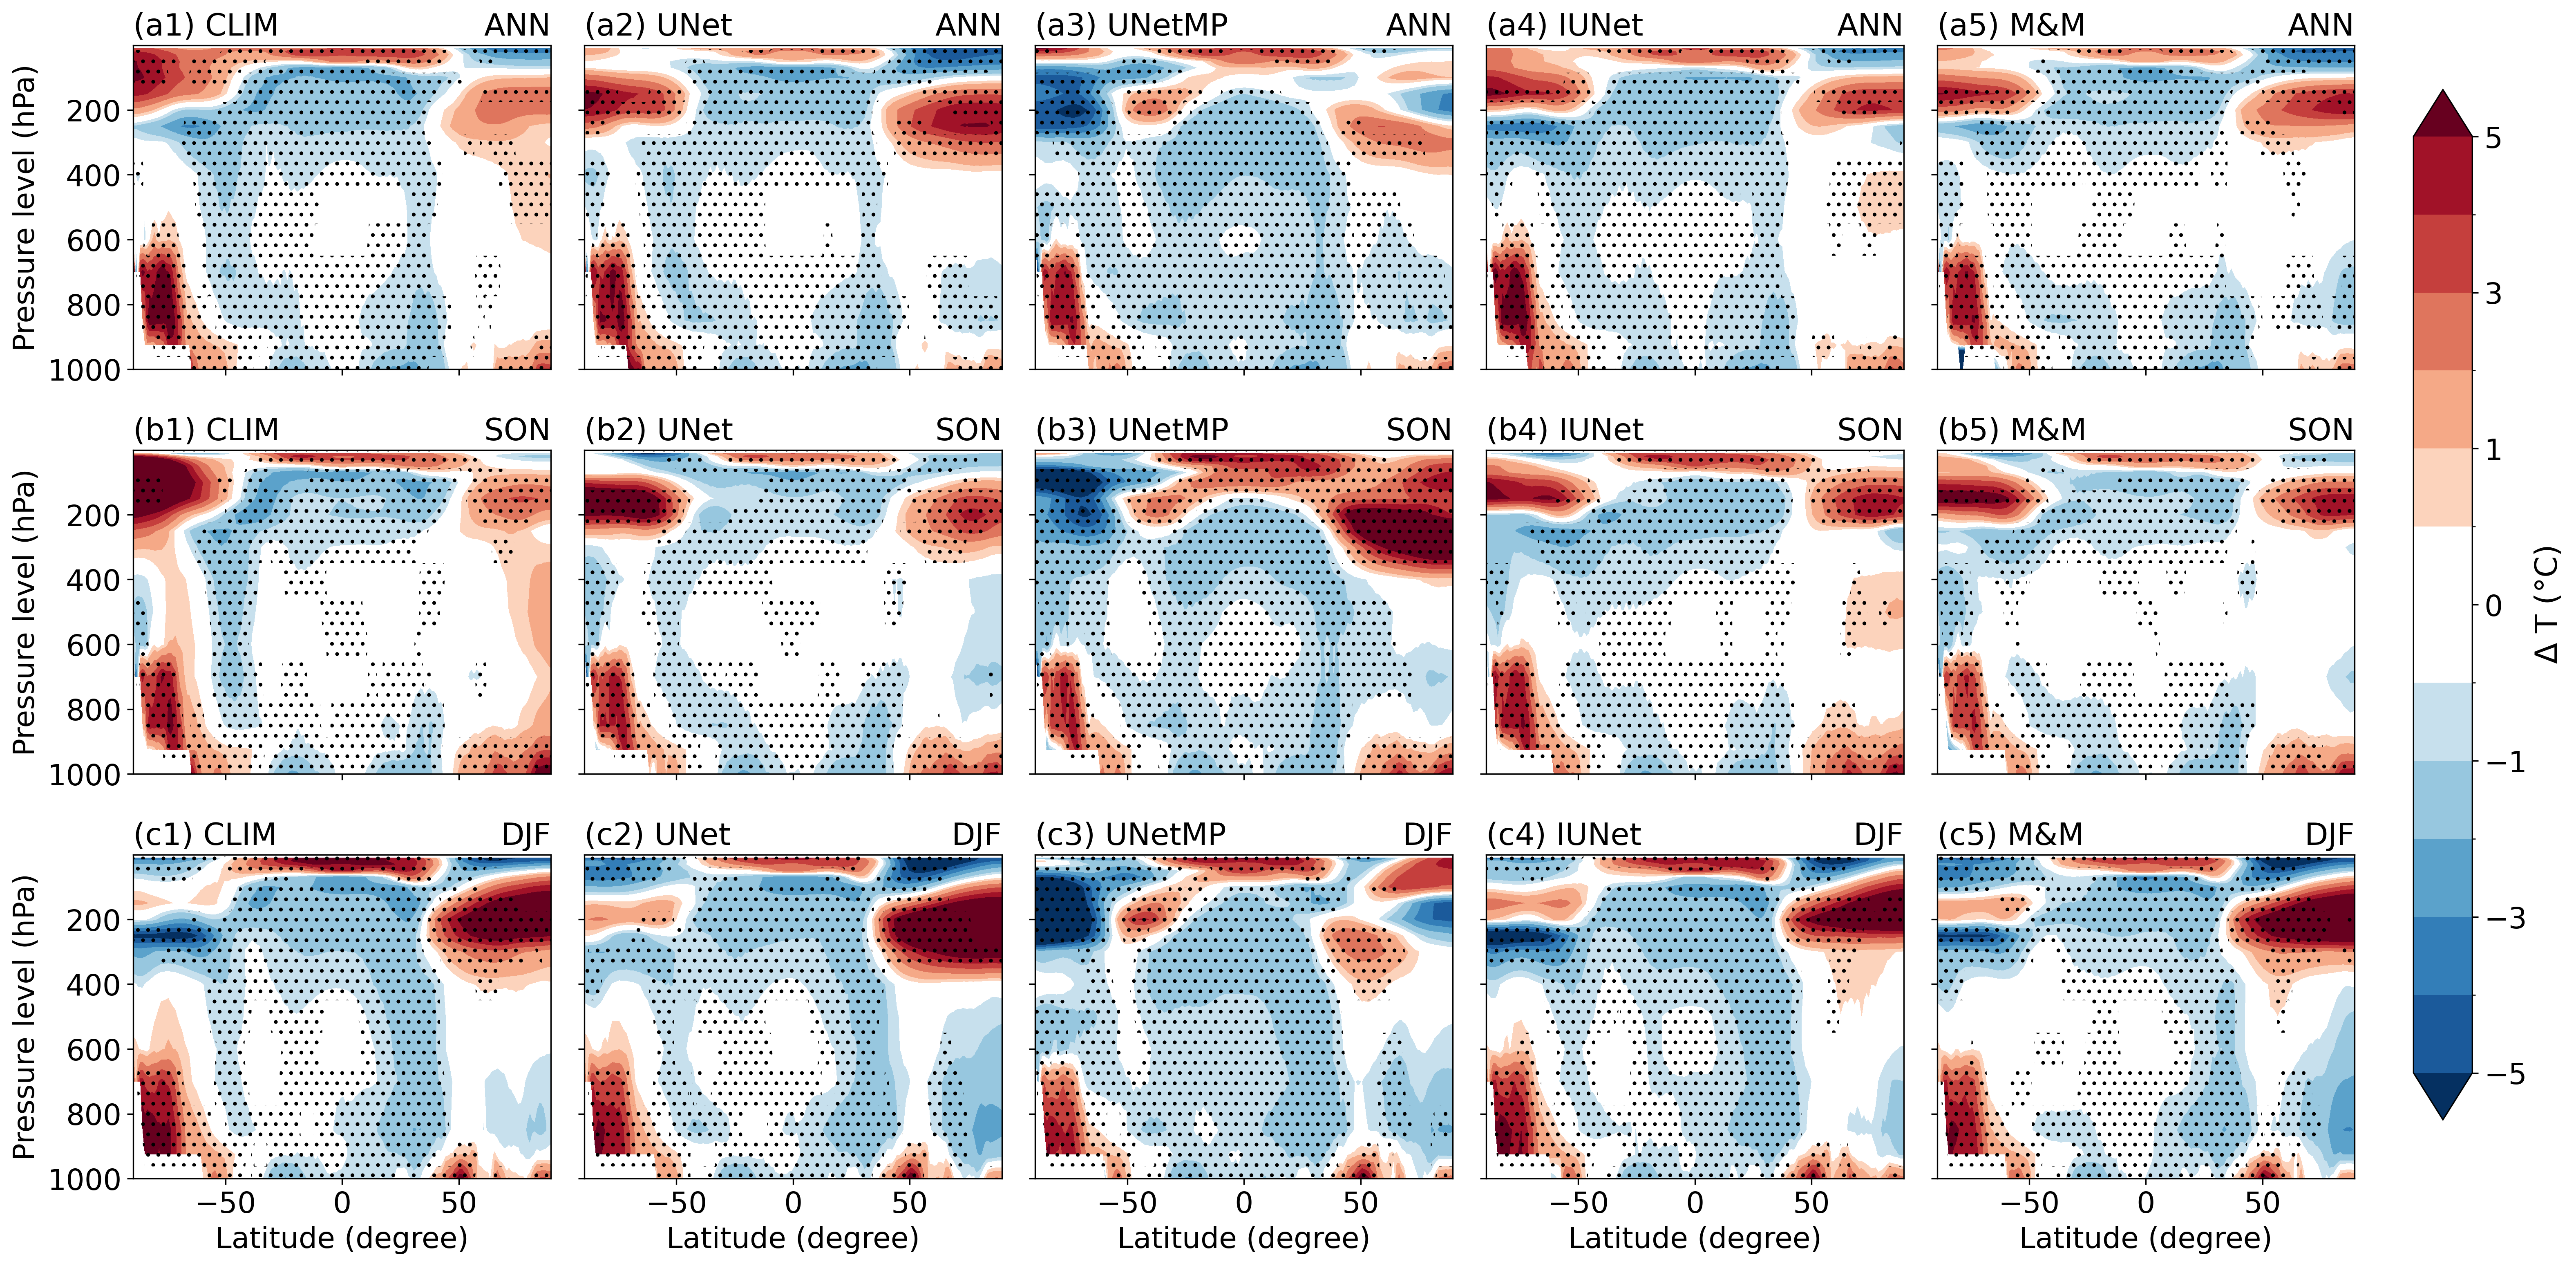

Saved: ./T_global_zonal_bias_ALLMODELS_201201_201612_ANN-SON-DJF.pdf


In [4]:
if __name__ == "__main__":
    # === Define Paths ===
    top_path  = "/pscratch/sd/z/zhan391/SEACROGS_project"
    work_path = f"{top_path}/paper_material/method_paper"
    out_path  = f"{work_path}/fig_data/zonal_bias"   # where calculator wrote NetCDFs (root)
    frequency = "monthly"                            # must match calculator.compute() path segment
    out_dir   = os.path.join(out_path, frequency)    # <out_path>/<frequency>
    fig_path  = "./"                                 # where to save PNGs
    os.makedirs(fig_path, exist_ok=True)

    # === Time / seasons ===
    period   = "201201_201612"   # must match calculator._period_label()
    seasons_all = ["DJF", "MAM", "JJA", "SON", "ANN"]
    seasons_row = ("ANN", "SON", "DJF")  # what to plot (rows)

    region = "global"
    var    = "T"                 # e.g., "U","V","T","Z","Q"
    exp    = "CLIM"              # single-experiment figure
    sigtyp = "hatch"
    metric = "zonal_bias" 
    pmin   = 10  #hPa
    pmax   = 1000 #hPa

    var_dict = {
        'U': {'alias': 'U',  'unit': 'm s$^{-1}$', 
              'fscl': 1.0, 'min': -5,  'max': 5,   
              'levs': [-5,-4,-3,-2,-1,-0.5,0.5,1,2,3,4,5]
             },
        'V': {'alias': 'V',  'unit': 'm s$^{-1}$', 
              'fscl': 1.0, 'min': -1,  'max': 1,   
              'levs': [-5,-4,-3,-2,-1,0,1,2,3,4,5]
             },
        'T': {'alias': 'T',  'unit': '°C',         
              'fscl': 1.0, 'min': -5,  'max': 5,   
              'levs': [-5,-4,-3,-2,-1,-0.5,0,0.5,1,2,3,4,5]
             },
        'Q': {'alias': 'Q',  'unit': 'g kg$^{-1}$',
              'fscl': 1.0,  'min': -1,  'max': 1,  
              'levs': [-5,-4,-3,-2,-1,-0.5,-0.2,0,0.2,0.5,1,2,3,4,5]
             },
        'Z': {'alias': 'Z3', 'unit': 'm',          
              'fscl': 1.0, 'min': -200,'max': 200, 
              'levs': [-5,-4,-3,-2,-1,-0.5,-0.2,0,0.2,0.5,1,2,3,4,5]
             },
    }
    vmin   = var_dict[var]['min']
    vmax   = var_dict[var]['max']
    nlevs  = len(var_dict[var]['levs'])
    levs   = var_dict[var]['levs']
    
    clim   = None
    dpi    = 300
    figsize =(24,12)

    # === Style (optional) ===
    fontsize = 18
    plt.rcParams.update({
        "font.size": fontsize,
        "axes.titlesize": fontsize * 0.9,
        "axes.labelsize": fontsize * 0.85,
        "xtick.labelsize": fontsize * 0.8,
        "ytick.labelsize": fontsize * 0.8,
        "legend.fontsize": fontsize * 0.75,
    })
    
    # === Experiments & variable setup ===
    exp_name_map = {
        "CLIM":   "CLIM",
        "UNet":   "UNet",
        "UNetMP": "UNetMP",
        "IUNet":  "IUNet",
        "MnM":    "M&M",
    }
    
    # Build file paths
    files = [
        os.path.join(out_dir, f"{var}_{region}_{metric}_{exp}_{period}.nc")
        for exp in exp_name_map.keys()
    ]
    
    # Corresponding labels
    labels = [exp_name_map[exp] for exp in exp_name_map.keys()]

    # === (Optional) keep a colormap handle for future tweaks ===
    index = np.linspace(0.05, 0.95, 20)
    newcmp = cm.RdYlBu_r

    # === Instantiate plotter ===
    plotter = E3SMBiasPlotter(
        out_dir=out_dir,
        region=region,
        metric=metric,
        seasons=seasons_all
    )

    fig, axes = plotter.plot_multi_model_zonal_contours(
        files=files,
        labels=labels,
        var=var,
        seasons=seasons_row,
        apply_sig=sigtyp,       # ← show significance with hatching
        pmin=pmin, 
        pmax=pmax,
        vmin=vmin,
        vmax=vmax,
        levels=levs, 
        nlevels=nlevs, 
        clim=clim,   # shared auto color scale
        figsize=figsize,
        fontsize=fontsize,
        dpi=dpi
    )
    outpdf = os.path.join(fig_path, f"{var}_{region}_{metric}_ALLMODELS_{period}_ANN-SON-DJF.pdf")
    fig.savefig(outpdf, dpi=dpi, bbox_inches="tight")
    plt.show()    
    plt.close(fig)
    print(f"Saved: {outpdf}")
    